In [2]:
# 1. Instalación
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.5 MB/s eta 0:00:00


In [3]:
# 2. Importaciones
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

from sklearn.model_selection import train_test_split

In [4]:
# 3. Configuración
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 20
LR = 1e-3

In [5]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/javiercamilogarcia
/kaggle/input/datasets/javiercamilogarcia/vertebras-columna
/kaggle/input/datasets/javiercamilogarcia/vertebras-columna/vertebras
/kaggle/input/datasets/javiercamilogarcia/vertebras-columna/vertebras/images
/kaggle/input/datasets/javiercamilogarcia/vertebras-columna/vertebras/masks


In [6]:
# 4. Paths
PATH_INPUT = '/kaggle/input/datasets/javiercamilogarcia/vertebras-columna/vertebras'
IMAGE_DIR = os.path.join(PATH_INPUT,'images')
MASK_DIR = os.path.join(PATH_INPUT,'masks')

image_paths = sorted([os.path.join(IMAGE_DIR, f) for f in os.listdir(IMAGE_DIR)])
mask_paths = sorted([os.path.join(MASK_DIR, f) for f in os.listdir(MASK_DIR)])

#for i in range(len(image_paths)):
 #   print(image_paths[i][len(PATH_INPUT)::], " ", mask_paths[i][len(PATH_INPUT)::])

In [7]:
# 5. Dataset
class VertebrasDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.masks[idx])
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

        mask = self.rgb_to_binary(mask)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        image = image.float()
        mask = mask.float()

        return image.float(), mask.unsqueeze(0).float()

    def rgb_to_binary(self, mask):
        # cualquier pixel con intensidad > 10 = vertebra
        return (np.sum(mask, axis=2) > 10).astype(np.float32)



In [8]:
# 6. Transformaciones

# Añade el paso de Normalize
transform_comun = [
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
]

train_transform = A.Compose([A.HorizontalFlip(p=0.5)] + transform_comun)
val_transform = A.Compose(transform_comun)

In [9]:
# 7. Split
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)

train_dataset = VertebrasDataset(train_imgs, train_masks, train_transform)
val_dataset = VertebrasDataset(val_imgs, val_masks, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [10]:
# 8. Modelo U-Net
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1
).to(DEVICE)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [28]:
# 9. Loss y optimizador
loss_fn = smp.losses.DiceLoss(mode='binary', from_logits=True)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [12]:
# 10. Métrica Dice
def dice_score(preds, targets, smooth=1e-6):
    preds = (preds > 0.5).float()
    intersection = (preds * targets).sum()
    return (2 * intersection + smooth) / (preds.sum() + targets.sum() + smooth)


In [29]:
# 11. Entrenamiento
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        preds = model(images)
        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_dice = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            preds = torch.sigmoid(model(images))
            val_dice += dice_score(preds, masks)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"Val Dice: {val_dice/len(val_loader):.4f}")


Epoch 1
Train Loss: 0.1106
Val Dice: 0.8950
Epoch 2
Train Loss: 0.0976
Val Dice: 0.8784
Epoch 3
Train Loss: 0.0923
Val Dice: 0.8939
Epoch 4
Train Loss: 0.0915
Val Dice: 0.8766
Epoch 5
Train Loss: 0.0880
Val Dice: 0.8969
Epoch 6
Train Loss: 0.0897
Val Dice: 0.8934
Epoch 7
Train Loss: 0.0854
Val Dice: 0.8978
Epoch 8
Train Loss: 0.0832
Val Dice: 0.9003
Epoch 9
Train Loss: 0.0942
Val Dice: 0.8135
Epoch 10
Train Loss: 0.1110
Val Dice: 0.8278
Epoch 11
Train Loss: 0.1199
Val Dice: 0.8169
Epoch 12
Train Loss: 0.1029
Val Dice: 0.8799
Epoch 13
Train Loss: 0.0948
Val Dice: 0.8991
Epoch 14
Train Loss: 0.0845
Val Dice: 0.9025
Epoch 15
Train Loss: 0.0830
Val Dice: 0.9027
Epoch 16
Train Loss: 0.0792
Val Dice: 0.9009
Epoch 17
Train Loss: 0.0764
Val Dice: 0.8950
Epoch 18
Train Loss: 0.0771
Val Dice: 0.9046
Epoch 19
Train Loss: 0.0741
Val Dice: 0.9056
Epoch 20
Train Loss: 0.0734
Val Dice: 0.9059


In [31]:
# 12. Predicción
def predict_image(model, image_path, transform):
    model.eval()
    
    # Leer imagen original
    image_cv = cv2.imread(image_path)
    image_cv = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = image_cv.shape[:2] # Guardamos alto y ancho originales

    # Aplicar EXACTAMENTE la misma transformación de validación
    # Esto maneja el Resize y el ToTensorV2 correctamente
    augmented = transform(image=image_cv)
    image_tensor = augmented['image'].unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        output = model(image_tensor)
        # Aplicamos sigmoid para obtener probabilidades entre 0 y 1
        probs = torch.sigmoid(output)[0][0].cpu().numpy()

    # Escalar la predicción (mapa de probabilidades) al tamaño original
    # Usamos INTER_LINEAR para suavizar las probabilidades
    probs_orig_size = cv2.resize(probs, (w_orig, h_orig), interpolation=cv2.INTER_LINEAR)

    # Umbral (Threshold) estándar para segmentación binaria
    mask_binary = (probs_orig_size > 0.5).astype(np.uint8)

    return image_cv, mask_binary

In [32]:
# 13. Visualización
def plot_prediction(original, pred): 
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.title("Imagen original")
    plt.imshow(original)
    plt.axis('off')
    
    plt.subplot(1,3,2)
    plt.title("Predicción (máscara)")
    plt.imshow(pred, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(original)
    plt.imshow(pred, alpha=0.5, cmap='jet')
    plt.axis('off')
    
    plt.show()

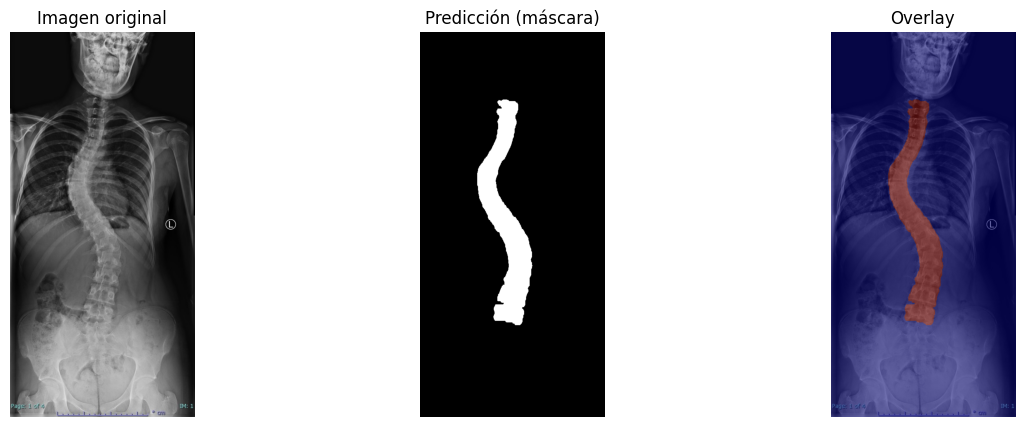

In [35]:
image_path = val_imgs[5]  # o cualquier imagen

original, pred = predict_image(model, image_path, val_transform)
plot_prediction(original, pred)

In [34]:
# Definir la ruta y nombre del archivo
MODEL_SAVE_PATH = "unet_resnet34_columna.pth"

# Guardar solo los pesos (es lo más eficiente y seguro)
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Modelo guardado exitosamente en: {MODEL_SAVE_PATH}")

Modelo guardado exitosamente en: unet_resnet34_columna.pth
